In [31]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/german_credit_data.csv")

df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               10000 non-null  int64 
 1   Sex               10000 non-null  object
 2   Job               10000 non-null  int64 
 3   Housing           10000 non-null  object
 4   Saving accounts   8987 non-null   object
 5   Checking account  8990 non-null   object
 6   Credit amount     10000 non-null  int64 
 7   Duration          10000 non-null  int64 
 8   Purpose           10000 non-null  object
 9   Risk              10000 non-null  object
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


0

In [ ]:
# 01 - EDA and Preprocessing

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path

DATA_PATH = Path("..") / "data" / "raw" / "german_credit_data.csv"

print(f"Loading data from: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print(df.head())
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isna().sum())


Loading data from: D:\projects\credit-risk-ml-pipeline\data\raw\german_credit_data.csv
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   56  female    2    rent        moderate             rich           4625   
1   69  female    0    rent          little           little          17026   
2   46  female    1     own          little              NaN          14531   
3   32  female    1    rent          little           little           3767   
4   60    male    1     own        moderate         moderate          16444   

   Duration    Purpose  Risk  
0        53        car  good  
1        15   radio/TV   bad  
2        10  furniture  good  
3        43  education  good  
4        45  furniture  good  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               10000 non-null  int64 

In [19]:

df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})


In [33]:

figures_dir = Path("..") / "reports" / "figures"   # from inside notebooks/
figures_dir.mkdir(parents=True, exist_ok=True)


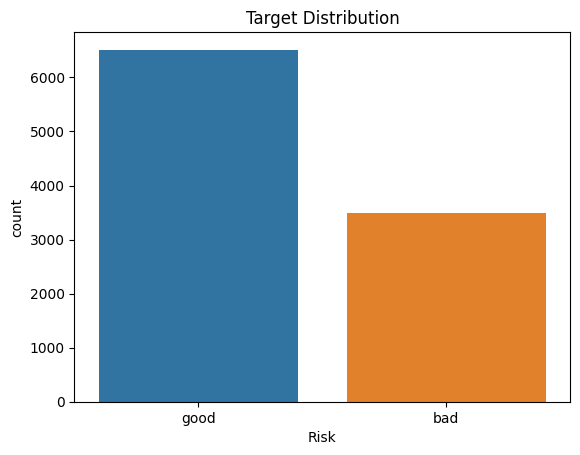

In [36]:

sns.countplot(x='Risk', data=df)
plt.title("Target Distribution")
plt.savefig(figures_dir / "countplot.png", dpi=300, bbox_inches="tight")
plt.show()


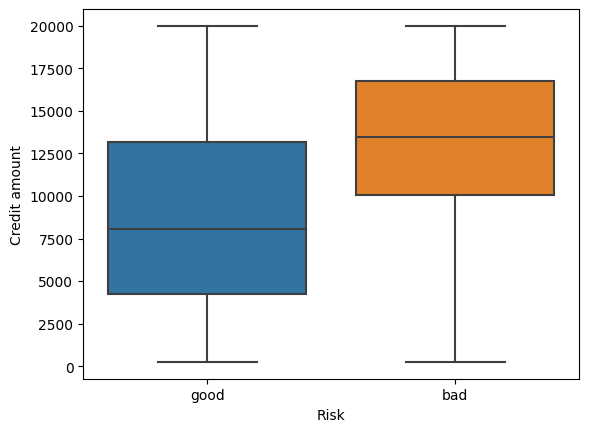

In [35]:
sns.boxplot(x='Risk', y='Credit amount', data=df)
plt.savefig(figures_dir / "boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


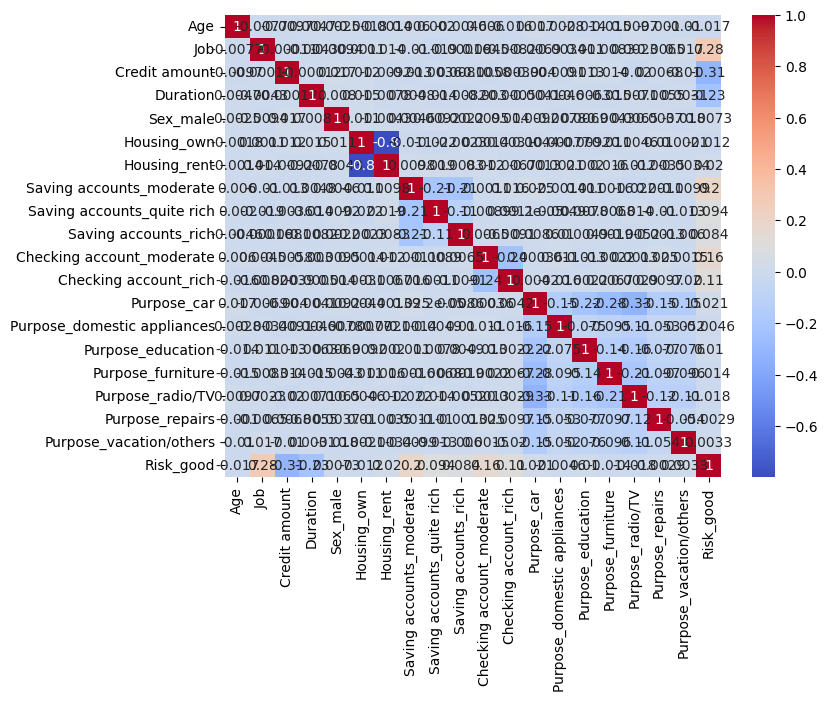

In [34]:

# 1. One-hot encode all categorical (object) columns
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Plot correlation heatmap on the encoded numeric data
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.savefig(figures_dir / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
df['Credit_to_Duration'] = df['Credit amount'] / df['Duration']
print(df['Credit_to_Duration'].head())

0      87.264151
1    1135.066667
2    1453.100000
3      87.604651
4     365.422222
Name: Credit_to_Duration, dtype: float64


In [25]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18,25,35,50,75],
    labels=['18-25','26-35','36-50','50+']
)
print(df['Age_Group'].head())

0      50+
1      50+
2    36-50
3    26-35
4      50+
Name: Age_Group, dtype: category
Categories (4, object): ['18-25' < '26-35' < '36-50' < '50+']


In [26]:
high_risk = ['business','education','vacation/others']

df['High_Risk_Purpose'] = df['Purpose'].apply(
    lambda x: 1 if x in high_risk else 0
)
print(df['High_Risk_Purpose'].head())

0    0
1    0
2    0
3    1
4    0
Name: High_Risk_Purpose, dtype: int64


In [27]:
df['Saving accounts'] = df['Saving accounts'].fillna('none')
df['Checking account'] = df['Checking account'].fillna('none')


In [28]:
df = pd.get_dummies(df, drop_first=True)


In [29]:
from sklearn.model_selection import train_test_split

X = df.drop('Risk', axis=1)
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

figures_dir = Path("..") / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Encoded Features)")
plt.savefig(figures_dir / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()